In [1]:
!pip install ultralytics kagglehub opencv-python matplotlib -q

import os
import shutil
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import kagglehub

path = kagglehub.dataset_download("ravirajsinh45/real-life-industrial-dataset-of-casting-product")

train_ok = []
train_def = []
test_ok = []
test_def = []

for root, dirs, files in os.walk(path):
    if "ok_front" in root and "train" in root:
        train_ok.append(root)
    if "def_front" in root and "train" in root:
        train_def.append(root)
    if "ok_front" in root and "test" in root:
        test_ok.append(root)
    if "def_front" in root and "test" in root:
        test_def.append(root)

train_ok = train_ok[0]
train_def = train_def[0]
test_ok = test_ok[0]
test_def = test_def[0]

dataset_path = "/content/yolo_dataset"

for split in ["train", "val"]:
    os.makedirs(f"{dataset_path}/images/{split}", exist_ok=True)
    os.makedirs(f"{dataset_path}/labels/{split}", exist_ok=True)

def process_images(src_path, label, split_type):
    images = os.listdir(src_path)
    random.shuffle(images)
    for img_name in images:
        src = os.path.join(src_path, img_name)
        dst_img = f"{dataset_path}/images/{split_type}/{img_name}"
        shutil.copy(src, dst_img)
        label_path = dst_img.replace("images", "labels").replace(".jpeg", ".txt")
        if label == 1:
            with open(label_path, "w") as f:
                f.write("0 0.5 0.5 1.0 1.0")
        else:
            open(label_path, "w").close()

process_images(train_def, 1, "train")
process_images(train_ok, 0, "train")
process_images(test_def, 1, "val")
process_images(test_ok, 0, "val")

yaml_content = f"""
path: {dataset_path}
train: images/train
val: images/val
names:
  0: defect
"""

with open(f"{dataset_path}/data.yaml", "w") as f:
    f.write(yaml_content)

model = YOLO("yolov8n.pt")

model.train(
    data=f"{dataset_path}/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    verbose=False
)

metrics = model.val()

print(metrics.box.map50)
print(metrics.box.map)

results = model.val(save_json=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 100M/100M [00:03<00:00, 33.8MB/s]

Extracting files...


Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

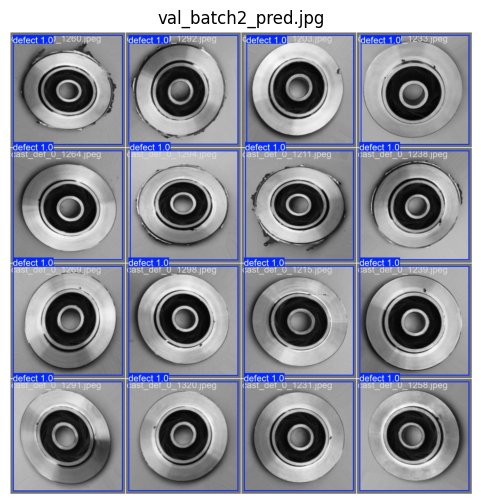

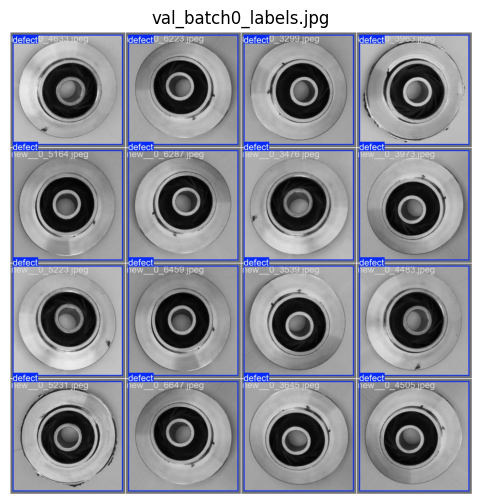

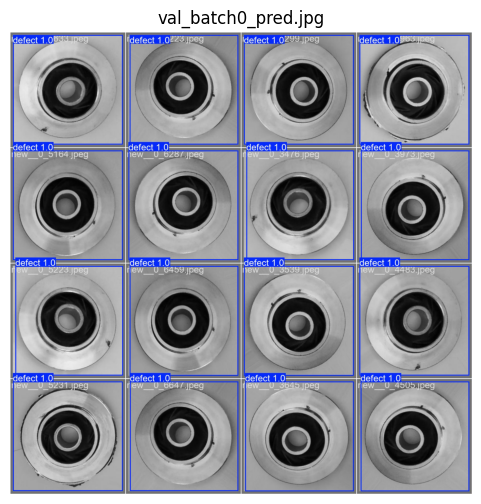

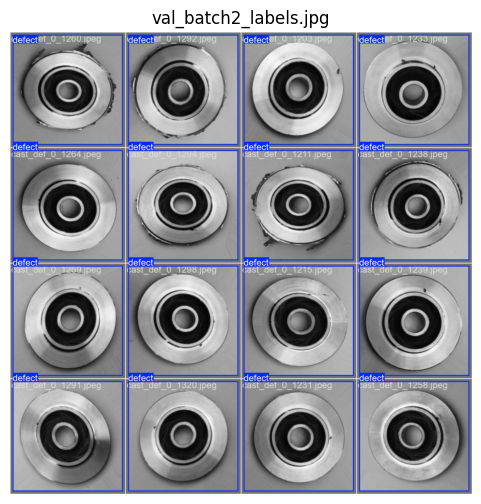

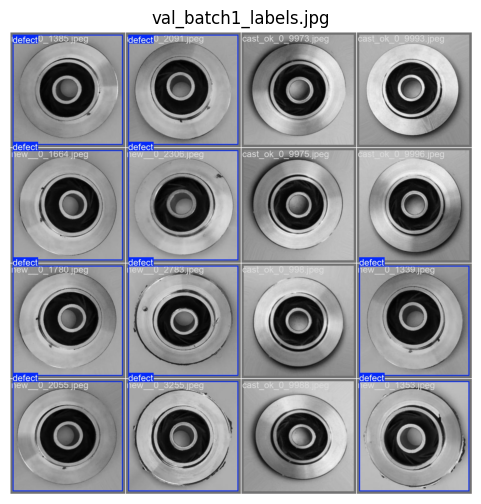

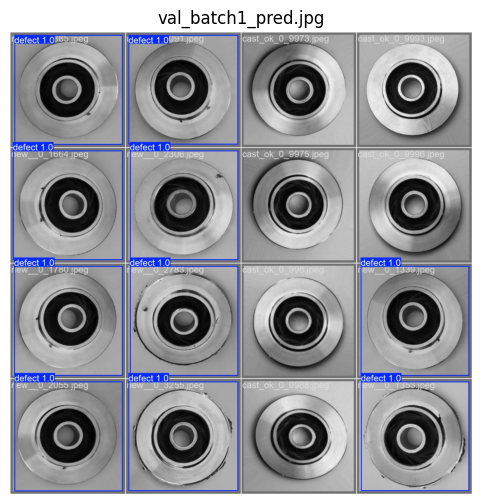

In [2]:
import os
import cv2
import matplotlib.pyplot as plt

result_dir = "/content/runs/detect/val-2"

for file in os.listdir(result_dir):
    if file.endswith(".jpg"):
        img_path = os.path.join(result_dir, file)

        img = cv2.imread(img_path)

        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(file)
        plt.axis("off")
        plt.show()

In [3]:
metrics = model.val()
print("Precision:", metrics.box.p.mean())
print("Recall:", metrics.box.r.mean())
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 420.6±107.3 MB/s, size: 10.0 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 715 images, 262 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 715/715 187.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 45/45 3.9it/s 11.5s
                   all        715        453          1      0.993      0.995      0.995
Speed: 3.6ms preprocess, 4.2ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val-3
Precision: 0.9999508896470585
Recall: 0.9933774834437086
mAP@0.5: 0.995
mAP@0.5:0.95: 0.9949999999999999
